<a href="https://colab.research.google.com/github/abikrishnanmsds25-web/WATER-QUALITY-CLASSIFICATION-FOR-SAFE-DRINKING-PREDICTION/blob/main/data_understanding.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()

Saving water_potability.csv to water_potability.csv


In [2]:
import pandas as pd

df = pd.read_csv('water_potability.csv')
df.head()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


This dataset contains water quality parameters such as pH, hardness, chloramines, etc. The target variable "Potability" indicates whether water is safe (1) or not (0).

In [3]:
df.shape

(3276, 10)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2785 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          2495 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3114 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB


In [6]:
df.describe()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
count,2785.000000,3276.000000,3276.000000,3276.000000,2495.000000,3276.000000,3276.000000,3114.000000,3276.000000,3276.000000
mean,7.080795,196.369496,22014.092526,7.122277,333.775777,426.205111,14.284970,66.396293,3.966786,0.390110
std,1.594320,32.879761,8768.570828,1.583085,41.416840,80.824064,3.308162,16.175008,0.780382,0.487849
min,0.000000,47.432000,320.942611,0.352000,129.000000,181.483754,2.200000,0.738000,1.450000,0.000000
25%,6.093092,176.850538,15666.690297,6.127421,307.699498,365.734414,12.065801,55.844536,3.439711,0.000000
50%,7.036752,196.967627,20927.833607,7.130299,333.073546,421.884968,14.218338,66.622485,3.955028,0.000000
75%,8.062066,216.667456,27332.762127,8.114887,359.950170,481.792304,16.557652,77.337473,4.500320,1.000000
max,14.000000,323.124000,61227.196008,13.127000,481.030642,753.342620,28.300000,124.000000,6.739000,1.000000


In [7]:
df.isnull().sum()

,0
ph,491
Hardness,0
Solids,0
Chloramines,0
Sulfate,781
Conductivity,0
Organic_carbon,0
Trihalomethanes,162
Turbidity,0
Potability,0


# Stage 3: Data Preprocessing & Cleaning

In [12]:
# Check missing values in each column
df.isnull().sum()

# Fill missing values using median (robust to outliers)
df.fillna(df.median(), inplace=True)

# Verify that missing values are handled
df.isnull().sum()

,0
ph,0
Hardness,0
Solids,0
Chloramines,0
Sulfate,0
Conductivity,0
Organic_carbon,0
Trihalomethanes,0
Turbidity,0
Potability,0


Missing values were handled using mean imputation to ensure completeness of the dataset.

In [11]:
df.duplicated().sum()

np.int64(0)

No duplicate records were found in the dataset, indicating good data quality.

In [13]:
# Check class distribution of target variable
df['Potability'].value_counts()

,count
Potability,
0,1998
1,1278


The dataset shows class imbalance between potable and non-potable water samples.

In [14]:
# Install SMOTE library
!pip install imbalanced-learn

# Import SMOTE
from imblearn.over_sampling import SMOTE

# Separate features and target variable
X = df.drop('Potability', axis=1)
y = df['Potability']

# Apply SMOTE to balance the dataset
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

# Check new class distribution
y_resampled.value_counts()

,count
Potability,
0,1998
1,1998


SMOTE (Synthetic Minority Oversampling Technique) was applied to balance the dataset by generating synthetic samples for the minority class.

In [15]:
# Import StandardScaler
from sklearn.preprocessing import StandardScaler

# Apply scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_resampled)

Feature scaling was performed using StandardScaler to normalize the feature values and improve model performance.

Completed Stage 3 data preprocessing with SMOTE and scaling

# Stage 4: Exploratory Data Analysis (EDA)

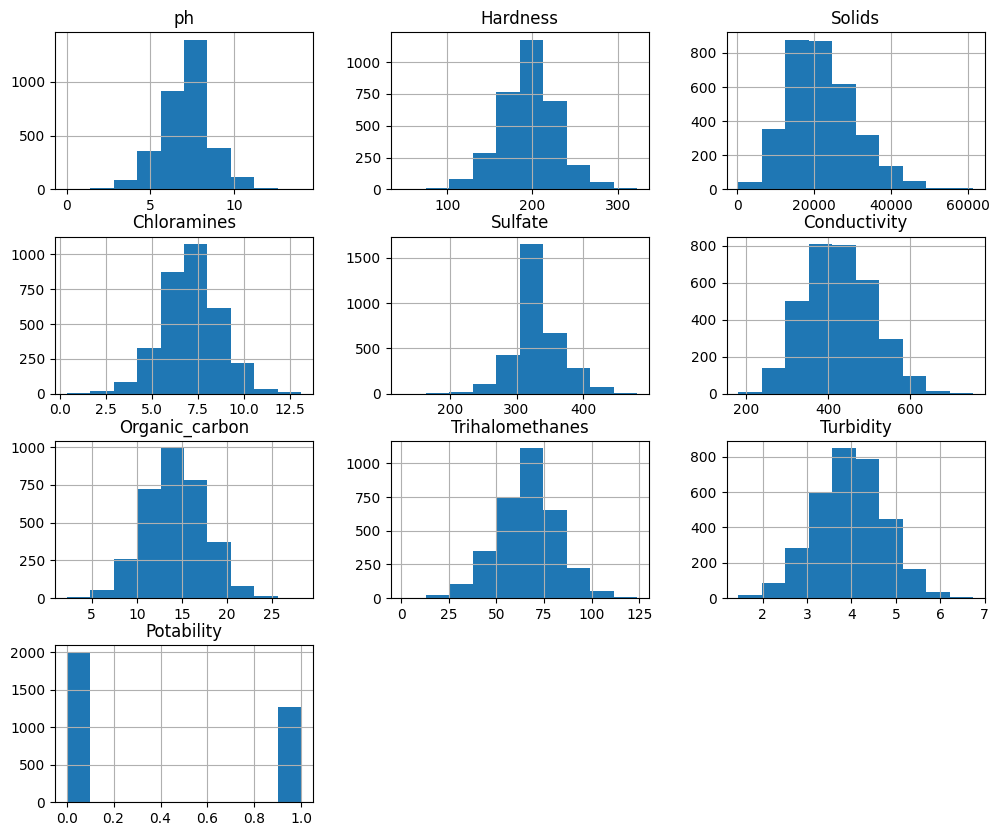

In [16]:
import matplotlib.pyplot as plt

# Plot histograms
df.hist(figsize=(12,10))
plt.show()

Histograms were used to visualize the distribution of each feature and understand their spread.

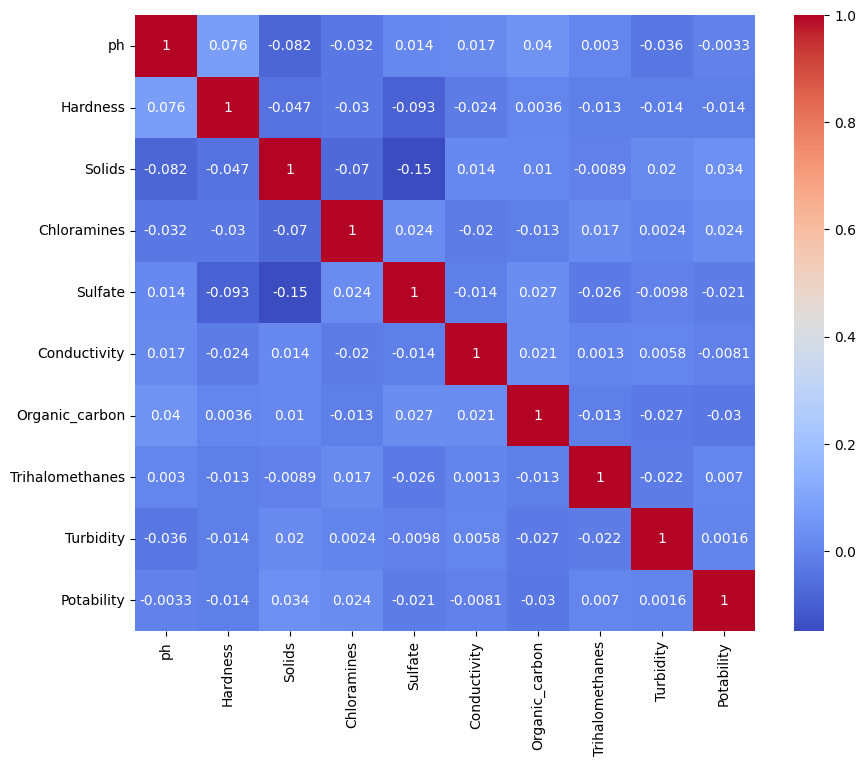

In [18]:
import seaborn as sns

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

A correlation heatmap was used to identify relationships between features and the target variable.

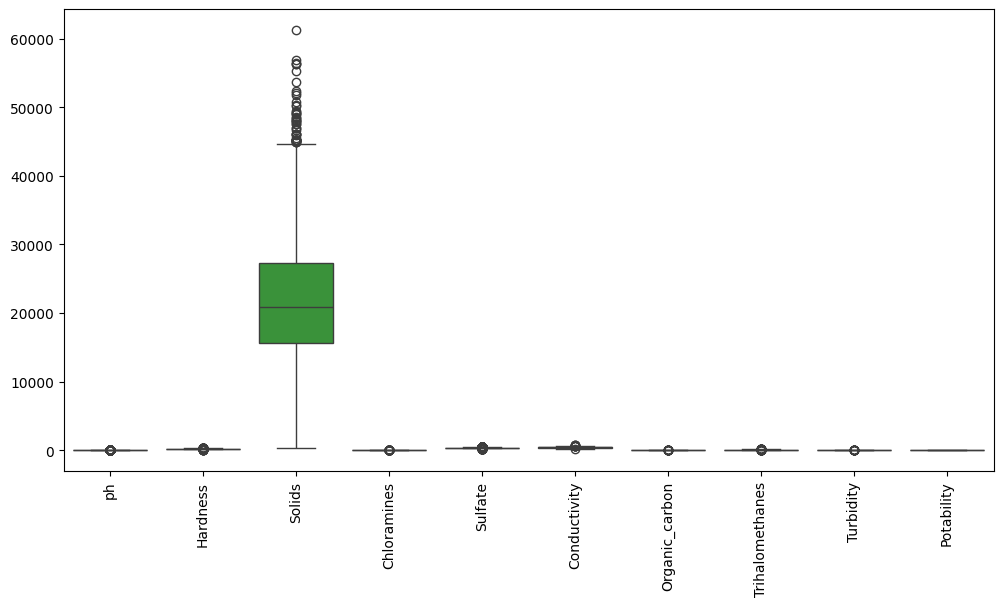

In [19]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.show()

Boxplots were used to detect outliers and understand variability in the data.

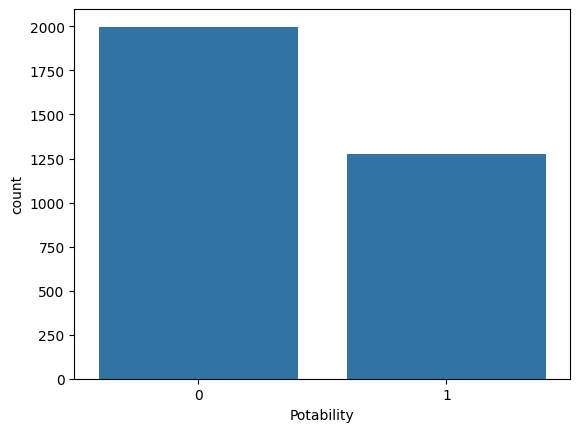

In [20]:
sns.countplot(x='Potability', data=df)
plt.show()

The distribution of the target variable shows the proportion of potable and non-potable water samples.

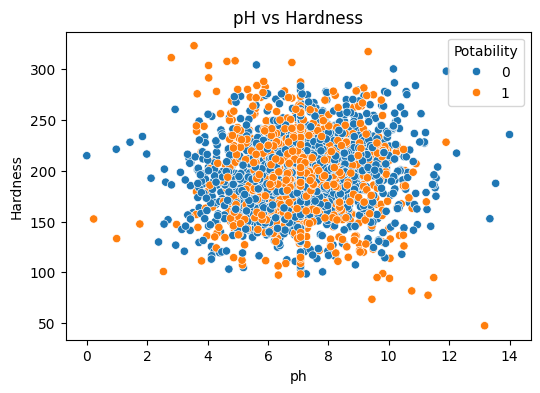

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

# Scatter plot between pH and Hardness
plt.figure(figsize=(6,4))
sns.scatterplot(x='ph', y='Hardness', hue='Potability', data=df)
plt.title("pH vs Hardness")
plt.show()

A scatter plot was used to analyze the relationship between pH and Hardness.
Color coding based on Potability helps identify patterns between safe and unsafe water samples.

In [21]:
df.groupby('Potability').mean()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity
Potability,,,,,,,,,
0,7.084658,196.733292,21777.490788,7.092175,334.371700,426.730454,14.364335,66.308522,3.965800
1,7.074754,195.800744,22383.991018,7.169338,332.844122,425.383800,14.160893,66.533513,3.968328


The mean values of features for potable and non-potable water were compared to identify important differences.

Completed Stage 4 EDA with visualizations and insights

# Stage 5: Feature Engineering & Selection

In [23]:
# Separate features and target variable
X = df.drop('Potability', axis=1)
y = df['Potability']

The dataset was divided into input features (X) and target variable (y) for further processing.


In [25]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Feature scaling was performed using StandardScaler to normalize the data and improve model performance.

In [26]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)
model.fit(X, y)

importances = model.feature_importances_

# Create dataframe
import pandas as pd
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

feature_importance

,Feature,Importance
0,ph,0.129176
4,Sulfate,0.128030
1,Hardness,0.122093
2,Solids,0.115762
3,Chloramines,0.115576
6,Organic_carbon,0.099438
5,Conductivity,0.098670
7,Trihalomethanes,0.097173
8,Turbidity,0.094082


Feature importance was calculated using Random Forest to identify the most influential variables affecting water potability.

In [27]:
# Select top 5 features
top_features = feature_importance['Feature'].head(5).tolist()

X_selected = X[top_features]

Top features were selected based on importance scores to reduce dimensionality and improve model efficiency.

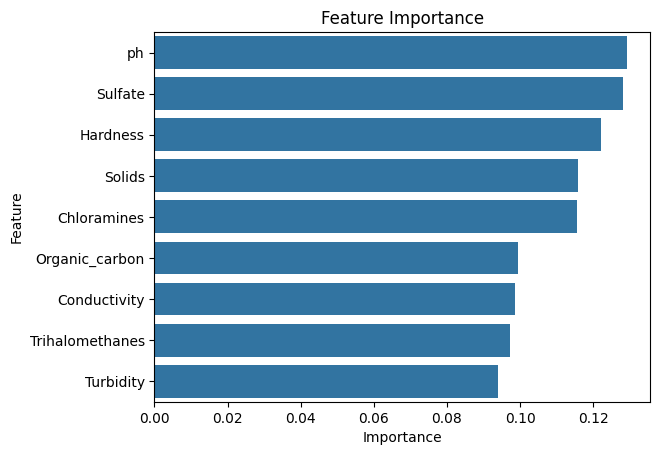

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(x='Importance', y='Feature', data=feature_importance)
plt.title("Feature Importance")
plt.show()

Completed Stage 5 feature engineering and selection